## Final Project - Part 3 of 3

# Part 2 Review

In Part 2 I modeled an over-damped spring mass-system with the base equation:

df/dt = -(k/c)x + (1/c)F(t)

where k/c =  5000s^-1, F(t) = 10sin(t), and x(0) = 1m. This system is unique because it is stiff, with a timescale ratio of 5000 between the exponential term and the sin term. In part 2 I found that methods such as Euler's Forward method required step sizes that were realistically too small (h < 0.0004) in order to remain stable and where too computationally taxing. I tried a new implicit method, Euler's Backward with Newton-Raphson iterations, which ended up being unconditionally stable (h > 0) and converged rapidly (2 or less iterations to achieve a y(n+1) within tolerance.

# Newton-Raphson Damping Implementation

The normal Newton-Raphson update is y^(k+1) = y^(k) - g(y^(k)) / g'(y^(k))

However, when the h value is too large or the initial guess is too far from the solution, the update can overshoot and diverge instead of converge. Dampening this process with a constant within the set (0,1] enables the scaling of the update to prevent divergence. This can be calculated by having the constant, a,  until abs(g(y^(k+1))) < abs(g(y^(k)))

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Residual
def g_func(y_new, y_n, t_next, h):
    return y_new - y_n - h * df(t_next, y_new)

# Residual Derivative
def g_prime_func(h):
    return 1 - h * (-5000)

def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        if abs(g) < tol:
            return y_guess, k, True

        g_prime = g_prime_func(h)
        delta = -g / g_prime

        # Damping Factor Calculation
        alpha = 1.0
        g_current = abs(g)
        for _ in range(10): 
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            if g_new < g_current:  # Sufficient decrease
                break
            alpha = alpha / 2.0

            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False

        y_guess = y_new

    return y_guess, max_iter, False

def euler_backward_damped(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y_0

    iters_list = []
    alpha_list = []
    damping_list = []

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        t_next = t_values[i]

        # Damped NR
        y_guess = y_n
        step_damped = False
        final_alpha = 1.0

        for k in range(20):
            g = g_func(y_guess, y_n, t_next, h)
            if abs(g) < 1e-8:
                iters_list.append(k + 1)
                break
            g_prime = g_prime_func(h)
            delta = -g / g_prime
            alpha = 1.0
            g_current = abs(g)
            for _ in range(10):
                y_new = y_guess + alpha * delta
                g_new = abs(g_func(y_new, y_n, t_next, h))
                if g_new < g_current:
                    break
                alpha /= 2.0
                if alpha < 1e-4:
                    break
            if alpha < 1.0:
                step_damped = True
            final_alpha = alpha
            y_guess = y_guess + alpha * delta
        else:
            iters_list.append(20)

        y_values[i] = y_guess
        alpha_list.append(final_alpha)
        damping_list.append(step_damped)

    return t_values, y_values, iters_list, alpha_list, damping_list

Dampening Demonstration

Undamped NR (h = 2.0)
Max abs(y): 1.000e+00
Mean NR iterations: 2.00

Damped NR (h = 2.0)
Max abs(y): 1.000e+00
Mean NR iterations: 2.00
Steps using damping: 0 / 5
Mean final alpha: 1.0000


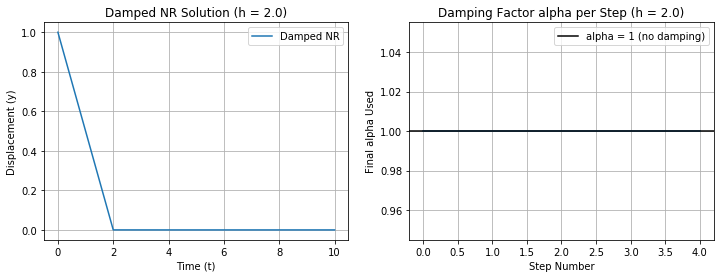

In [2]:
# Part 2 Functions
def df(t, y):
    k = 25000000
    c = 5000
    f = 10*np.sin(t)
    return -(k/c)*y + (1/c)*f

def nr_method(i, y, t, h):
    ynew = y[i-1]
    iterations = 0
    for j in range(15):
        g = ynew - y[i-1] - h*df(t[i],ynew)
        gprime = 1 - h*(-5000)
        ynew = ynew - g/gprime
        iterations = j + 1
        if np.abs(g) < 1e-6:
            break
    return ynew, iterations

def euler_backward_method(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    iters = []
    # Initial Conditions
    y_values[0] = y_0
    
    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        # Update Equations
        y_values[i], iterations = nr_method(i, y_values, t_values, h)
        iters.append(iterations)
    return t_values, y_values, iters

# Wrapper
def nr_solver_damped(y_n, t_next, h):
    y_out, iters, converged = damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func)
    return y_out, iters

# Undamped NR
def nr_solver_basic(y_n, t_next, h):
    y_guess = y_n
    for k in range(20):
        g = g_func(y_guess, y_n, t_next, h)
        if abs(g) < 1e-8:
            return y_guess, k + 1
        g_prime = g_prime_func(h)
        y_guess = y_guess - g / g_prime
    return y_guess, 20

h_large = 2.0
t_start, t_end, y_0 = 0, 10, 1

print("Undamped NR (h = 2.0)")
t_u, y_u, iters_u = euler_backward_method(h_large, t_start, t_end, y_0)
print(f"Max abs(y): {np.max(np.abs(y_u)):.3e}")
print(f"Mean NR iterations: {np.mean(iters_u):.2f}")

print("\nDamped NR (h = 2.0)")
t_d, y_d, iters_d, alphas_d, damp_flags = euler_backward_damped(
    h_large, t_start, t_end, y_0
)
print(f"Max abs(y): {np.max(np.abs(y_d)):.3e}")
print(f"Mean NR iterations: {np.mean(iters_d):.2f}")
print(f"Steps using damping: {sum(damp_flags)} / {len(damp_flags)}")
print(f"Mean final alpha: {np.mean(alphas_d):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_d, y_d, label='Damped NR')
axes[0].set_xlabel('Time (t)')
axes[0].set_ylabel('Displacement (y)')
axes[0].set_title('Damped NR Solution (h = 2.0)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(len(alphas_d)), alphas_d)
axes[1].axhline(y=1.0, color='k', label='alpha = 1 (no damping)')
axes[1].set_xlabel('Step Number')
axes[1].set_ylabel('Final alpha Used')
axes[1].set_title('Damping Factor alpha per Step (h = 2.0)')
axes[1].legend()
axes[1].grid(True)

plt.show()

In this example, the system being linear actually didn't activate because the Newton is trivially unstable. Therefor, in this case, damping was unnecessary.

# Adaptive Size Implementation

Due to the inefficiency of the fixed step size it is difficult to accurately display both the exponential transience and the slow sinusoidal force. Adaptive step sizes estimate the local error and can adjust the h accordingly and efficiently. 

In [3]:
def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    """
    Estimate error using step-doubling (Richardson extrapolation).

    1. Take ONE step of size h
    2. Take TWO steps of size h/2
    3. Compare the results

    Returns: (y_full, y_half, error, total_nr_iters)
    """
    # Single step of size h
    y_full, iters_full = nr_solver(y_n, t_n + h, h)

    # Two half-steps of size h/2
    y_half_1, iters_1 = nr_solver(y_n, t_n + h/2, h/2)
    y_half,   iters_2 = nr_solver(y_half_1, t_n + h, h/2)

    error = abs(y_half - y_full)
    total_iters = iters_full + iters_1 + iters_2

    return y_full, y_half, error, total_iters


def adaptive_step(y_n, t_n, h, tol, nr_solver,
                  h_min=1e-6, h_max=1.0, safety=0.9):
    """
    Take one adaptive step with error control.

    Returns: (y_next, h_used, h_new, accepted, iters)
    """
    y_full, y_half, error, iters = estimate_error_step_doubling(
        y_n, t_n, h, nr_solver
    )

    # Compute suggested next step size
    if error < 1e-14:
        h_new = min(2.0 * h, h_max)
    else:
        h_new = h * np.sqrt(tol / error)
        h_new = safety * h_new
        h_new = max(h_min, min(h_max, h_new))

    # Don't change h too dramatically in one step
    h_new = max(0.2 * h, min(5.0 * h, h_new))

    if error < tol:
        # ACCEPT: use the more accurate two-half-step result
        return y_half, h, h_new, True, iters
    else:
        # REJECT: don't advance, suggest smaller h
        return y_n, h, h_new, False, iters


def adjust_step_size(h_current, error, tol, safety=0.9,
                     h_min=1e-6, h_max=1.0):
    """
    Compute new step size based on error estimate.
    Uses: h_new = h * sqrt(tol / err)
    """
    if error < 1e-14:
        h_new = h_current * 2.0
    else:
        h_new = h_current * np.sqrt(tol / error)

    h_new = safety * h_new
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    return h_new


def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol, h_min=1e-6, h_max=1.0, nr_tol=1e-8, max_nr_iter=20):
    """
    Adaptive Euler's Backward with damped Newton-Raphson.

    Parameters:
    - f:          ODE function (unused directly; g_func uses df)
    - y0:         initial condition
    - t0, t_final: time span
    - h0:         initial step size
    - tol:        error tolerance
    - h_min/h_max: step size bounds
    - nr_tol:     Newton-Raphson convergence tolerance
    - max_nr_iter: max NR iterations per step

    Returns: t, y, h_history, stats
    """
    t = [t0]
    y = [y0]
    h = h0
    h_history = []

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0
    }

    def nr_solver(y_n, t_next, h_step):
        y_out, iters, converged = damped_newton_raphson(y_n, t_next, h_step, g_func, g_prime_func, tol=nr_tol, max_iter=max_nr_iter)
        return y_out, iters

    while t[-1] < t_final:
        t_n = t[-1]
        y_n = y[-1]

        # Overshoot Limit
        if t_n + h > t_final:
            h = t_final - t_n

        y_next, h_used, h_new, accepted, iters = adaptive_step(
            y_n, t_n, h, tol, nr_solver,
            h_min=h_min, h_max=h_max
        )

        stats['nr_iterations'].append(iters)
        stats['function_evals'] += iters

        if accepted:
            t.append(t_n + h_used)
            y.append(y_next)
            h_history.append(h_used)
            stats['accepted_steps'] += 1
        else:
            stats['rejected_steps'] += 1

        h = h_new

    return np.array(t), np.array(y), h_history, stats

Accepted steps:  126
Rejected steps:  5
Total NR iters:  393
Acceptance rate: 96.2%


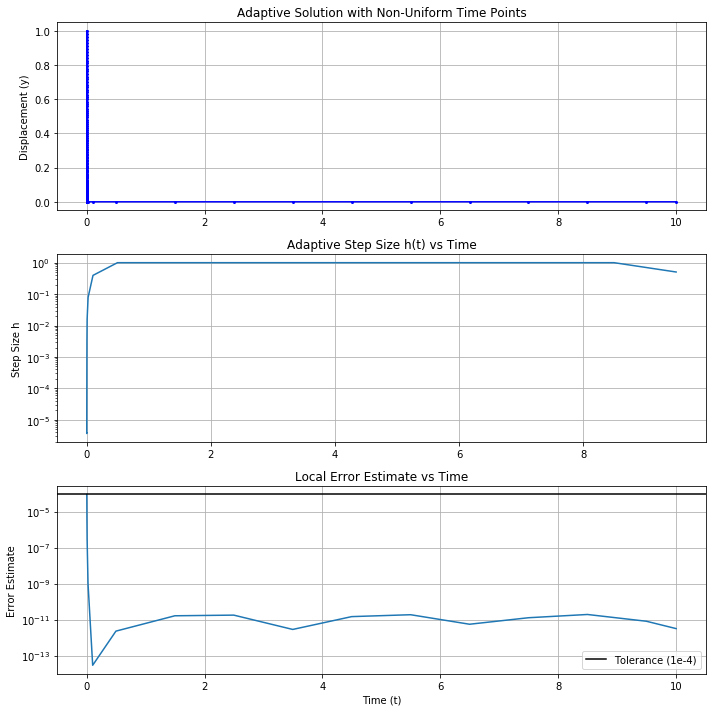

In [4]:
t_adapt, y_adapt, h_hist, stats = adaptive_implicit_euler(df, y_0, t_start, t_end, h0=0.01, tol=1e-4)

print(f"Accepted steps:  {stats['accepted_steps']}")
print(f"Rejected steps:  {stats['rejected_steps']}")
print(f"Total NR iters:  {stats['function_evals']}")
print(f"Acceptance rate: "f"{stats['accepted_steps']/(stats['accepted_steps']+stats['rejected_steps'])*100:.1f}%")

# Recompute Error History
err_hist = []
for i in range(1, len(t_adapt)):
    y_n = y_adapt[i-1]
    t_n = t_adapt[i-1]
    h_i = h_hist[i-1]
    _, _, err, _ = estimate_error_step_doubling(y_n, t_n, h_i, lambda yn, tn, hs: damped_newton_raphson(yn, tn, hs, g_func, g_prime_func)[:2])
    err_hist.append(err)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

axes[0].plot(t_adapt, y_adapt, 'b-o', markersize=2)
axes[0].set_ylabel('Displacement (y)')
axes[0].set_title('Adaptive Solution with Non-Uniform Time Points')
axes[0].grid(True)

axes[1].semilogy(t_adapt[:-1], h_hist)
axes[1].set_ylabel('Step Size h')
axes[1].set_title('Adaptive Step Size h(t) vs Time')
axes[1].grid(True)

axes[2].semilogy(t_adapt[1:], err_hist)
axes[2].axhline(y=1e-4, color='k', label='Tolerance (1e-4)')
axes[2].set_ylabel('Error Estimate')
axes[2].set_xlabel('Time (t)')
axes[2].set_title('Local Error Estimate vs Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

 The adaptive step size vs time graph shows how the system responds to the fast transience with smaller h values and then grows h significantly once the solution is stabilized into the slow sinusoidal forcing behavior. 

# Performance Analysis

Method                    Steps   Func Evals    Final Error
------------------------------------------------------------
Fixed h=0.001             10000        10009      3.044e-14
Fixed h=0.005              2001         2007      1.181e-13
Fixed h=0.01               1000         1005      2.251e-13
Fixed h=0.05                200          376      1.068e-12
Adaptive tol=0.001           50          165      4.852e-12
Adaptive tol=0.0001         126          393      4.758e-12
Adaptive tol=1e-05          366         1115      6.248e-12


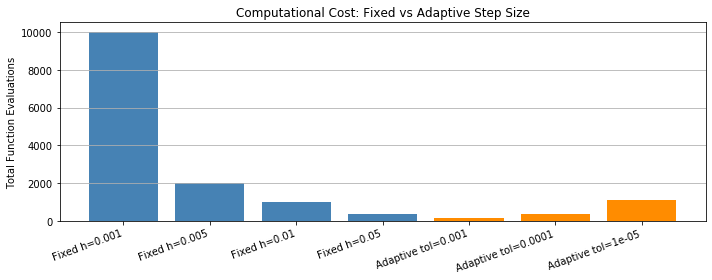

In [5]:
def f_exact(t):
    A, B, C = 4e-7, -8e-11, y_0
    return C*np.exp(-5000*t) + A*np.sin(t) + B*np.cos(t)

fixed_hs = [0.001, 0.005, 0.01, 0.05]
results = []

for h in fixed_hs:
    t_f, y_f, iters_f = euler_backward_method(h, t_start, t_end, y_0)
    total_fe = int(np.sum(iters_f))
    final_err = np.abs(y_f[-1] - f_exact(t_f[-1]))
    results.append((f'Fixed h={h}', len(t_f)-1, total_fe, final_err))

for tol in [1e-3, 1e-4, 1e-5]:
    t_a, y_a, h_hist_a, stats_a = adaptive_implicit_euler(df, y_0, t_start, t_end, h0=0.01, tol=tol)
    total_fe = stats_a['function_evals']
    final_err = np.abs(y_a[-1] - f_exact(t_a[-1]))
    results.append((f'Adaptive tol={tol}',
                    stats_a['accepted_steps'], total_fe, final_err))

print(f"{'Method':<22} {'Steps':>8} {'Func Evals':>12} {'Final Error':>14}")
print("-" * 60)
for row in results:
    print(f"{row[0]:<22} {row[1]:>8} {row[2]:>12} {row[3]:>14.3e}")

methods = [r[0] for r in results]
func_evals = [r[2] for r in results]
colors = ['steelblue']*len(fixed_hs) + ['darkorange']*3

plt.figure(figsize=(10, 4))
plt.bar(methods, func_evals, color=colors)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Total Function Evaluations')
plt.title('Computational Cost: Fixed vs Adaptive Step Size')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

Accepted steps:  126
Rejected steps:  7
Acceptance rate: 94.7%


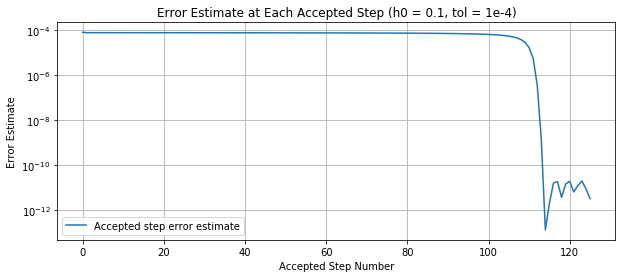

In [6]:
t_adapt2, y_adapt2, h_hist2, stats2 = adaptive_implicit_euler(df, y_0, t_start, t_end, h0=0.1, tol=1e-4)

# Recompute Error Estimates
err_hist2 = []
for i in range(len(h_hist2)):
    y_n = y_adapt2[i]
    t_n = t_adapt2[i]
    h_i = h_hist2[i]
    _, _, err, _ = estimate_error_step_doubling(y_n, t_n, h_i, lambda yn, tn, hs: damped_newton_raphson(yn, tn, hs, g_func, g_prime_func)[:2])
    err_hist2.append(err)

print(f"Accepted steps:  {stats2['accepted_steps']}")
print(f"Rejected steps:  {stats2['rejected_steps']}")
print(f"Acceptance rate: "
      f"{stats2['accepted_steps']/(stats2['accepted_steps']+stats2['rejected_steps'])*100:.1f}%")

plt.figure(figsize=(10, 4))
plt.semilogy(range(len(err_hist2)), err_hist2, label='Accepted step error estimate')
plt.xlabel('Accepted Step Number')
plt.ylabel('Error Estimate')
plt.title('Error Estimate at Each Accepted Step (h0 = 0.1, tol = 1e-4)')
plt.legend()
plt.grid(True)

As shown in the error estimate graph, the adaptive method keeps the error estimate just below the tolerance and drops off sharply at high accepted step number values.

# Robustness Testing

In [7]:
# Large Initial h
t_r1, y_r1, h_r1, stats_r1 = adaptive_implicit_euler(df, y_0, t_start, t_end, h0=1.0, tol=1e-4)
print("h0 = 1.0, tol = 1e-4")
print(f"Accepted: {stats_r1['accepted_steps']}, "f"Rejected: {stats_r1['rejected_steps']}")
print(f"Total NR iterationss: {stats_r1['function_evals']}")
print(f"Min h used: {min(h_r1):.2e}, Max h used: {max(h_r1):.2e}")

h0 = 1.0, tol = 1e-4
Accepted: 126, Rejected: 10
Total NR iterationss: 407
Min h used: 3.67e-06, Max h used: 1.00e+00


In [8]:
# Tight Tolerance
t_r2, y_r2, h_r2, stats_r2 = adaptive_implicit_euler(df, y_0, t_start, t_end, h0=0.01, tol=1e-5)
print("\nh0 = 0.01, tol = 1e-8")
print(f"Accepted: {stats_r2['accepted_steps']}, "f"Rejected: {stats_r2['rejected_steps']}")
print(f"Total NR iterations: {stats_r2['function_evals']}")
print(f"Min h used: {min(h_r2):.2e}, Max h used: {max(h_r2):.2e}")


h0 = 0.01, tol = 1e-8
Accepted: 366, Rejected: 6
Total NR iterations: 1115
Min h used: 1.15e-06, Max h used: 1.00e+00


With a step size of 1, many rejections arise early on in the solution due to the error vastly exceeding the tolerance, hence why there are 10 rejections. With a tight tolerance the solver tightened the h value but requires much more function evaluations due to the halving of the h value to reach the desired tolerance. In both cases the solver is able to gracefully adjust h values to stay within tolerance.

# Conclusion

Through this project I've learned about the necessity of iteration and step dampening, which arrises when step sizes are too large, tolerances are too slow, or the residuals from the Newton-Raphson method cause overshoots. In this system g'(y) is constant and g(y) is linear, which allows it to be extremely robust. Adaptive step sizes become worth the complexity when handling stiff systems like this one which have varying time scales, like the fast initial transience and the slow sinusoidal portion of the graph. A fixed solver would be unable to accurately graph both dynamics and would likely blow up when using a reasonable tolerance, such as Euler Forward (explicit methods). The adaptive solver is able to focus process power on the portions requiring higher order accuracy and take liberty on portions of the graph with slower forcing dynamics. During this portion of the project I learned about the pitfalls of standard implicit methods, in the way that they are unconditionally stable but not always accurate. Using dampening techniques in addition to implicit solving I am able to create and efficient, accurate, and unconditionally stable system that can fit within essentially any reasonable tolerance. 

# Bonus

Bonus 3

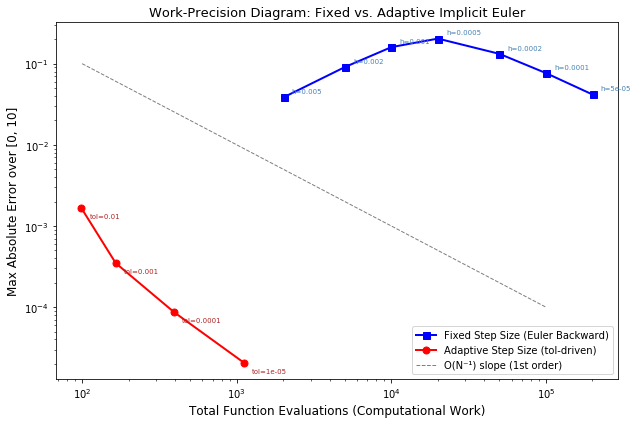


Method                         Func Evals      Max Error
---------------------------------------------------------
Fixed h=0.005                        2007      3.846e-02
Fixed h=0.002                        5007      9.086e-02
Fixed h=0.001                       10009      1.599e-01
Fixed h=0.0005                      20012      2.036e-01
Fixed h=0.0002                      50020      1.321e-01
Fixed h=0.0001                     100033      7.657e-02
Fixed h=5e-05                      200056      4.172e-02

Adaptive tol=0.01                      99      1.654e-03
Adaptive tol=0.001                    165      3.483e-04
Adaptive tol=0.0001                   393      8.680e-05
Adaptive tol=1e-05                   1115      2.063e-05


In [9]:
fixed_hs = [0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001, 0.00005]
fixed_fe, fixed_err = [], []

for h in fixed_hs:
    t_f, y_f, iters_f = euler_backward_method(h, t_start, t_end, y_0)
    total_fe = int(np.sum(iters_f))
    err = np.max(np.abs(y_f - f_exact(t_f)))
    fixed_fe.append(total_fe)
    fixed_err.append(err)

tolerances = [1e-2, 1e-3, 1e-4, 1e-5]
adapt_fe, adapt_err = [], []

for tol in tolerances:
    t_a, y_a, h_hist_a, stats_a = adaptive_implicit_euler(
        df, y_0, t_start, t_end, h0=0.01, tol=tol
    )
    total_fe = stats_a['function_evals']
    t_fine = np.linspace(t_start, t_end, 5000)
    y_interp = np.interp(t_fine, t_a, y_a)
    err = np.max(np.abs(y_interp - f_exact(t_fine)))
    adapt_fe.append(total_fe)
    adapt_err.append(err)

plt.figure(figsize=(9, 6))
plt.loglog(fixed_fe, fixed_err, 'bs-', markersize=7, linewidth=2, label='Fixed Step Size (Euler Backward)')
plt.loglog(adapt_fe, adapt_err, 'ro-', markersize=7, linewidth=2, label='Adaptive Step Size (tol-driven)')

for fe, err, h in zip(fixed_fe, fixed_err, fixed_hs):
    plt.annotate(f'h={h}', xy=(fe, err), xytext=(8, 4), textcoords='offset points', fontsize=7, color='steelblue')
for fe, err, tol in zip(adapt_fe, adapt_err, tolerances):
    plt.annotate(f'tol={tol}', xy=(fe, err), xytext=(8, -10), textcoords='offset points', fontsize=7, color='firebrick')

fe_ref = np.array([1e2, 1e5])
plt.loglog(fe_ref, 1e-1 * (fe_ref / fe_ref[0])**(-1), 'k--', linewidth=1, alpha=0.5, label='O(N⁻¹) slope (1st order)')

plt.xlabel('Total Function Evaluations (Computational Work)', fontsize=12)
plt.ylabel('Max Absolute Error over [0, 10]', fontsize=12)
plt.title('Work-Precision Diagram: Fixed vs. Adaptive Implicit Euler', fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n{'Method':<28} {'Func Evals':>12} {'Max Error':>14}")
print("-" * 57)
for h, fe, err in zip(fixed_hs, fixed_fe, fixed_err):
    print(f"{'Fixed h='+str(h):<28} {fe:>12} {err:>14.3e}")
print()
for tol, fe, err in zip(tolerances, adapt_fe, adapt_err):
    print(f"{'Adaptive tol='+str(tol):<28} {fe:>12} {err:>14.3e}")

Bonus 1

Method                      Accepted   Rejected   Func Evals
------------------------------------------------------------
Basic Controller                 126          5          393
PI Controller                    117          6          369


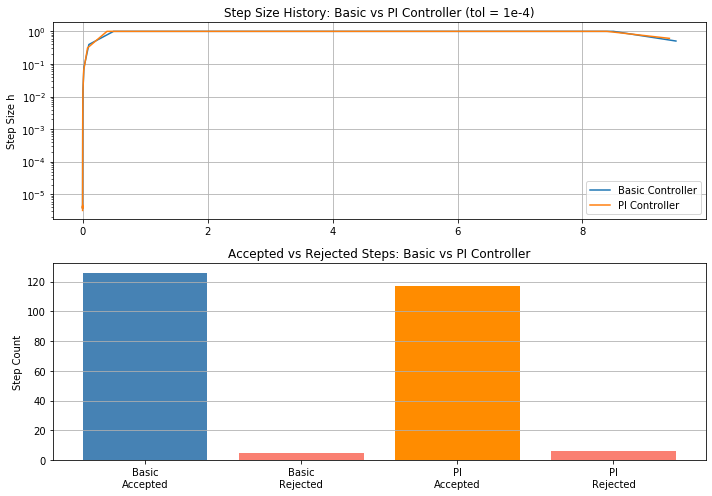

In [10]:
def adjust_step_size_PI(h_current, error, error_prev, tol, kP=0.7, kI=0.4, safety=0.9, h_min=1e-6, h_max=1.0):
    # Bounds
    error = max(error, 1e-14)
    error_prev = max(error_prev, 1e-14)

    h_new = safety * h_current * (tol / error)**kP * (tol / error_prev)**kI

    # Enforce Bounds
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))
    h_new = max(h_min, min(h_max, h_new))

    return h_new


def adaptive_implicit_euler_PI(f, y0, t0, t_final, h0, tol, h_min=1e-6, h_max=1.0, nr_tol=1e-8, max_nr_iter=20, kP=0.7, kI=0.4):
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    error_prev = tol

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0
    }

    def nr_solver(y_n, t_next, h_step):
        y_out, iters, converged = damped_newton_raphson(y_n, t_next, h_step, g_func, g_prime_func, tol=nr_tol, max_iter=max_nr_iter)
        return y_out, iters

    while t[-1] < t_final:
        t_n = t[-1]
        y_n = y[-1]

        if t_n + h > t_final:
            h = t_final - t_n

        y_full, y_half, error, iters = estimate_error_step_doubling(y_n, t_n, h, nr_solver)

        stats['nr_iterations'].append(iters)
        stats['function_evals'] += iters

        # PI Controller
        h_new = adjust_step_size_PI(h, error, error_prev, tol, kP=kP, kI=kI, h_min=h_min, h_max=h_max)

        if error < tol:
            t.append(t_n + h)
            y.append(y_half)
            h_history.append(h)
            stats['accepted_steps'] += 1
            error_prev = error
        else:
            stats['rejected_steps'] += 1
        h = h_new

    return np.array(t), np.array(y), h_history, stats


# Basic vs PI controller
t_basic, y_basic, h_hist_basic, stats_basic = adaptive_implicit_euler(df, y_0, t_start, t_end, h0=0.01, tol=1e-4)

t_pi, y_pi, h_hist_pi, stats_pi = adaptive_implicit_euler_PI(df, y_0, t_start, t_end, h0=0.01, tol=1e-4)

print(f"{'Method':<25} {'Accepted':>10} {'Rejected':>10} {'Func Evals':>12}")
print("-" * 60)
print(f"{'Basic Controller':<25} {stats_basic['accepted_steps']:>10} "
      f"{stats_basic['rejected_steps']:>10} {stats_basic['function_evals']:>12}")
print(f"{'PI Controller':<25} {stats_pi['accepted_steps']:>10} "
      f"{stats_pi['rejected_steps']:>10} {stats_pi['function_evals']:>12}")

# Plot step size histories side by side
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

axes[0].semilogy(t_basic[:-1], h_hist_basic, label='Basic Controller')
axes[0].semilogy(t_pi[:-1], h_hist_pi, label='PI Controller')
axes[0].set_ylabel('Step Size h')
axes[0].set_title('Step Size History: Basic vs PI Controller (tol = 1e-4)')
axes[0].legend()
axes[0].grid(True)

axes[1].bar(['Basic\nAccepted', 'Basic\nRejected', 'PI\nAccepted',    'PI\nRejected'], [stats_basic['accepted_steps'], stats_basic['rejected_steps'], stats_pi['accepted_steps'],    stats_pi['rejected_steps']], color=['steelblue', 'salmon', 'darkorange', 'salmon'])
axes[1].set_ylabel('Step Count')
axes[1].set_title('Accepted vs Rejected Steps: Basic vs PI Controller')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()